# INITIALIZATION OF THE LOAN PREDICTION MODEL
This data set would provide you enough taste of working on data sets from insurance companies, what challenges are faced, what strategies are used, which variables influence the outcome etc. This is a classification problem. 

This is used to automate the loan eligibility process (real time) based on customer detail provided while filling online application form. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns


from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder # for scaling and encoding
from sklearn.model_selection import train_test_split


loan_df = pd.read_csv('Loan_Prediction.csv')
loan_df.head(11)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [2]:
# PERFORMING EDA (Exploratory data Analysis)
loan_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


In [3]:
loan_df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [4]:
# CHECKING IF THERE ARE ANY DUPLICATES AND REMOVING THEM

print("No. of duplicated values are: ",loan_df.duplicated().sum(),'\n')
# CHECKING THE NO. OF NULL VALUES IN THE FEATURES
print("Columns with the number of null values:\n",loan_df.isnull().sum())


No. of duplicated values are:  0 

Columns with the number of null values:
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [5]:
# FILLING THE NULL NUMERICAL VALUES WITH A SUITABLE ALTERNATIVE (mean/mode)

loan_df['LoanAmount'] =  loan_df['LoanAmount'].fillna(loan_df['LoanAmount'].median())
loan_df['Loan_Amount_Term'] =  loan_df['Loan_Amount_Term'].fillna(loan_df['Loan_Amount_Term'].median())
loan_df['Credit_History'] = loan_df['Credit_History'].fillna(loan_df['Credit_History'].median())

In [6]:
# PRINTING OUT ALL THE UNIQUE VALUES IN CATEGORICAL COLUMNS TO ENSURE PROPER ALIGNMENT
print("THE UNIQUE DEPENDENTS VALUES ARE: ",loan_df['Dependents'].unique())
print("THE UNIQUE GENDER VALUES ARE: ",loan_df['Gender'].unique())
print("THE UNIQUE MARITAL STATUS VALUES ARE: ",loan_df['Married'].unique())
print("THE UNIQUE EMPLOYMENT VALUES ARE: ",loan_df['Self_Employed'].unique())
print("THE UNIQUE EDUCATION VALUES ARE: ",loan_df['Education'].unique())
print("THE UNIQUE PROPERTY VALUES ARE: ",loan_df['Property_Area'].unique())

THE UNIQUE DEPENDENTS VALUES ARE:  <ArrowStringArray>
['0', '1', '2', '3+', nan]
Length: 5, dtype: str
THE UNIQUE GENDER VALUES ARE:  <ArrowStringArray>
['Male', 'Female', nan]
Length: 3, dtype: str
THE UNIQUE MARITAL STATUS VALUES ARE:  <ArrowStringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
THE UNIQUE EMPLOYMENT VALUES ARE:  <ArrowStringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
THE UNIQUE EDUCATION VALUES ARE:  <ArrowStringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str
THE UNIQUE PROPERTY VALUES ARE:  <ArrowStringArray>
['Urban', 'Rural', 'Semiurban']
Length: 3, dtype: str


In [7]:
# Replace "3+" with "3" so it can be a valid string , then convert
loan_df['Dependents'] = loan_df['Dependents'].replace('3+', '3')
loan_df['Dependents'] = pd.to_numeric(loan_df['Dependents'], errors='coerce')  # NaNs stay 
loan_df['Dependents'] =  loan_df['Dependents'].fillna(loan_df['Dependents'].median())

In [8]:
loan_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         614 non-null    float64
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(5), int64(1), str(7)
memory usage: 82.7 KB


In [9]:
# DELETING THE NULL VALUES FROM THE GENDER, SELF_EMPLOYED AND MARRIED FEATURES 
loan_df = loan_df.dropna(subset=['Gender', 'Self_Employed', 'Married'])
print("Columns with the number of null values:\n",loan_df.isnull().sum())


Columns with the number of null values:
 Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


IMPLEMENTATION OF ONE-HOT ENCODING FOR CATEGIRICAL FEATURES

In [10]:
# PUTTING ALL CATEGORICAL_COLUMNS IN A LIST EXCLUDING LOAN_ID

categorical_columns = loan_df.select_dtypes('str').columns.tolist()
categorical_columns.remove('Loan_ID')
categorical_columns.remove('Loan_Status')
categorical_columns

['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']

In [11]:
# ENCODING THE TARGET FEATURE
loan_df['Loan_Status'] = loan_df['Loan_Status'].map({'Y': 1, 'N': 0})

In [12]:
#Initializing the Encoder

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoder.fit_transform(loan_df[categorical_columns])

array([[1., 0., 0., 0., 0., 1.],
       [1., 1., 0., 0., 0., 0.],
       [1., 1., 0., 1., 0., 1.],
       ...,
       [1., 1., 0., 0., 0., 1.],
       [1., 1., 0., 0., 0., 1.],
       [0., 0., 0., 1., 1., 0.]], shape=(566, 6))

In [13]:
# ILLUSTRATION OF HOW THE ENCODER IDENTIFIES THE CATEGORIES
encoder.categories_
# GENERATING COLUMN NAMES FOR EACH INDIVIDUAL CATEGORY USING get_feature_names
encoded_cols = encoder.get_feature_names_out(categorical_columns)
print(encoded_cols)



['Gender_Male' 'Married_Yes' 'Education_Not Graduate' 'Self_Employed_Yes'
 'Property_Area_Semiurban' 'Property_Area_Urban']


In [14]:
# PERFORMING ENCODING USING THE transform() METHOD
loan_df[encoded_cols] = encoder.transform(loan_df[categorical_columns])
# YOU CAN CHECK PRESENCE OF ADDED ENCODED COLUMNS USING 
# loan_df.head(5)

DATA VISUALIZATION OF FEATURE RELATIONSHIP

In [19]:
loan_df.info()

<class 'pandas.DataFrame'>
Index: 566 entries, 0 to 613
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Loan_ID                  566 non-null    str    
 1   Gender                   566 non-null    str    
 2   Married                  566 non-null    str    
 3   Dependents               566 non-null    float64
 4   Education                566 non-null    str    
 5   Self_Employed            566 non-null    str    
 6   ApplicantIncome          566 non-null    int64  
 7   CoapplicantIncome        566 non-null    float64
 8   LoanAmount               566 non-null    float64
 9   Loan_Amount_Term         566 non-null    float64
 10  Credit_History           566 non-null    float64
 11  Property_Area            566 non-null    str    
 12  Loan_Status              566 non-null    int64  
 13  Gender_Male              566 non-null    float64
 14  Married_Yes              566 non-null    f

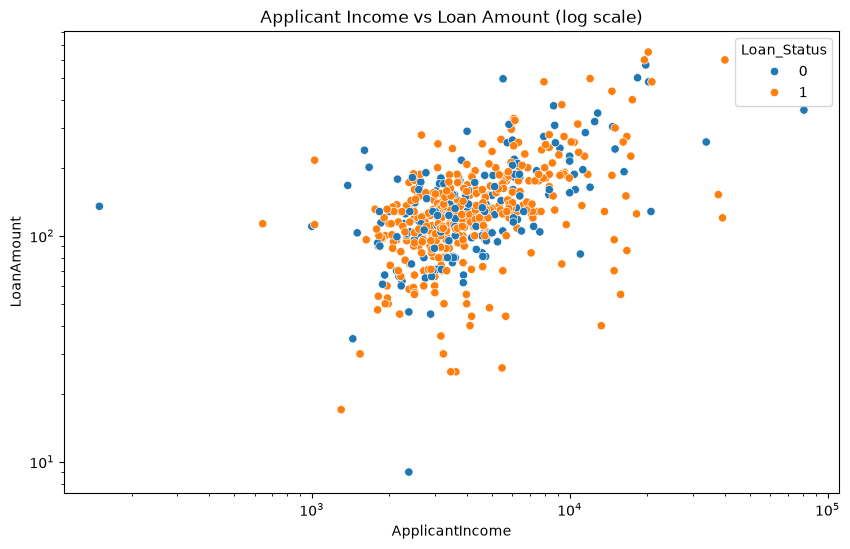

In [ ]:
# PLOTTING GRAPH OF APPLICANTS INCOME AGAINST LOAN AMOUNT USING A LOG SCALE

plt.figure(figsize=(10, 6))
sns.scatterplot(data=loan_df, x='ApplicantIncome', y='LoanAmount', hue='Loan_Status')
plt.xscale('log')
plt.yscale('log')
plt.title('Applicant Income vs Loan Amount (log scale)')
plt.show()

<Axes: xlabel='ApplicantIncome', ylabel='Count'>

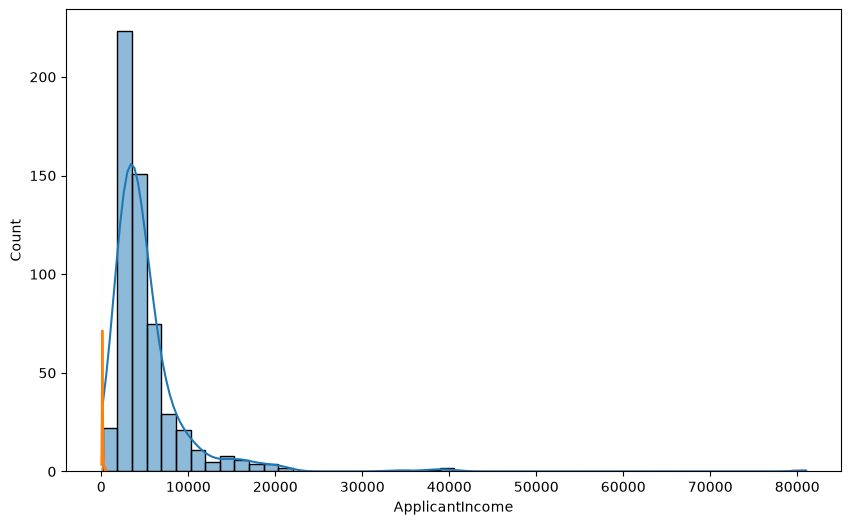

In [23]:
# Numeric distributions plot
plt.figure(figsize=(10, 6))
sns.histplot(data=loan_df, x='ApplicantIncome', kde=True)
sns.histplot(data=loan_df, x='LoanAmount', kde=True)


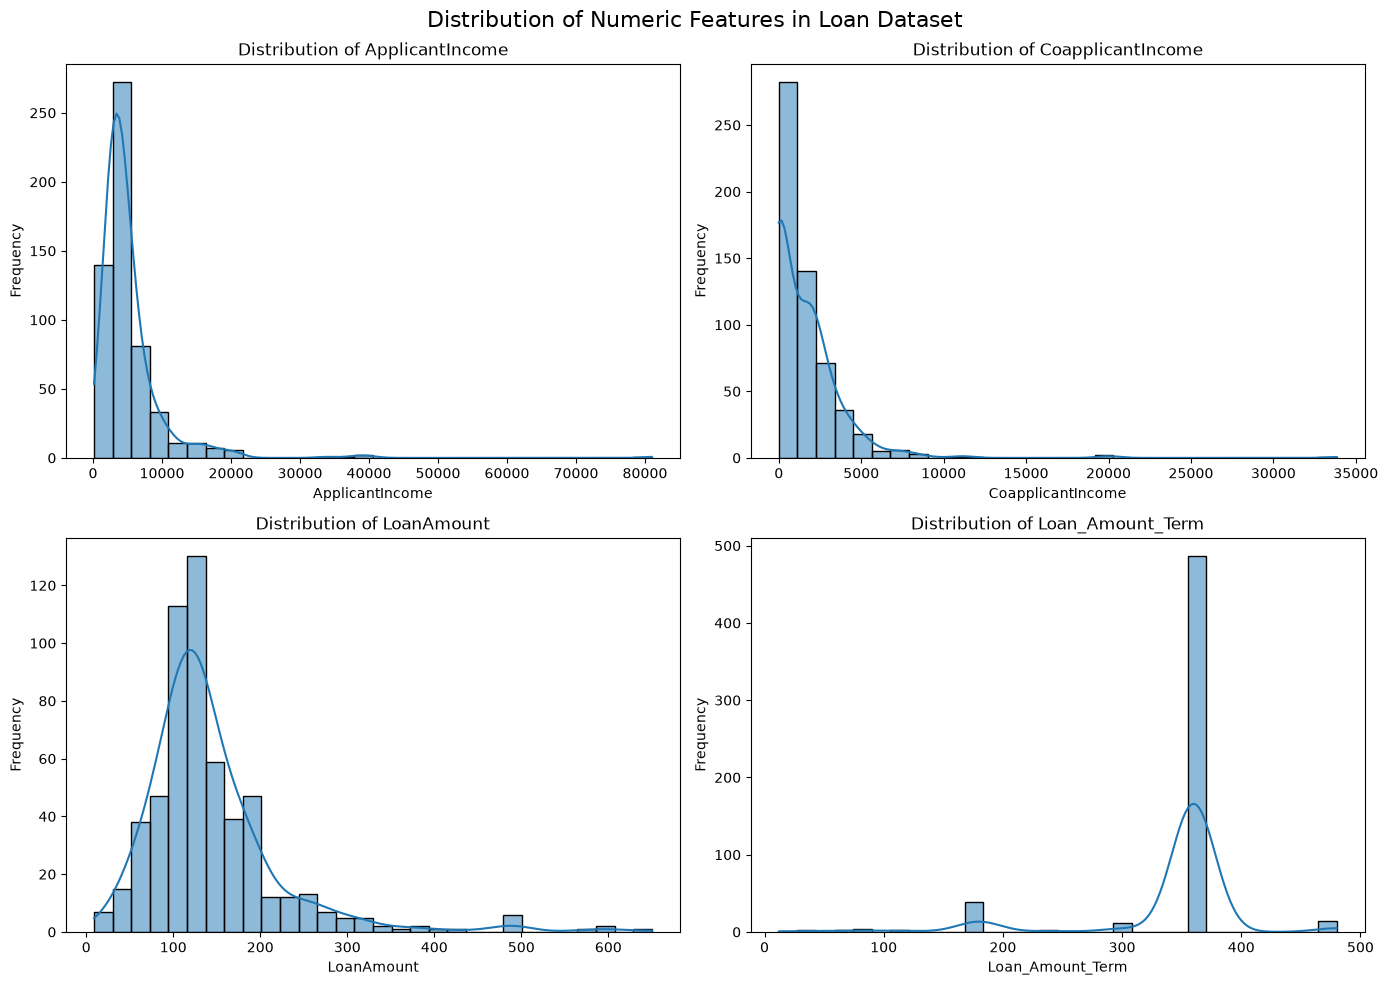

In [29]:
# Adding EDA visualizations  for loan prediction logistic regression
numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=loan_df, x=col, kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Numeric Features in Loan Dataset', fontsize=16)
plt.tight_layout()
plt.show()

TRAINING A LOGISTIC REGRESSION MODEL

In [15]:
# Save the full cleaned+encoded dataset once before splitting
loan_df.to_csv('loan_data_cleaned_encoded.csv', index=False)

# Creating  modeling dataframe by dropping the original categorical columns, keeping only numeric + encoded columns
loan_model_df = loan_df.drop(columns=categorical_columns)
loan_model_df.head(5)

,Loan_ID,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,0.0,5849,0.0,128.0,360.0,1.0,1,1.0,0.0,0.0,0.0,0.0,1.0
1,LP001003,1.0,4583,1508.0,128.0,360.0,1.0,0,1.0,1.0,0.0,0.0,0.0,0.0
2,LP001005,0.0,3000,0.0,66.0,360.0,1.0,1,1.0,1.0,0.0,1.0,0.0,1.0
3,LP001006,0.0,2583,2358.0,120.0,360.0,1.0,1,1.0,1.0,1.0,0.0,0.0,1.0
4,LP001008,0.0,6000,0.0,141.0,360.0,1.0,1,1.0,0.0,0.0,0.0,0.0,1.0


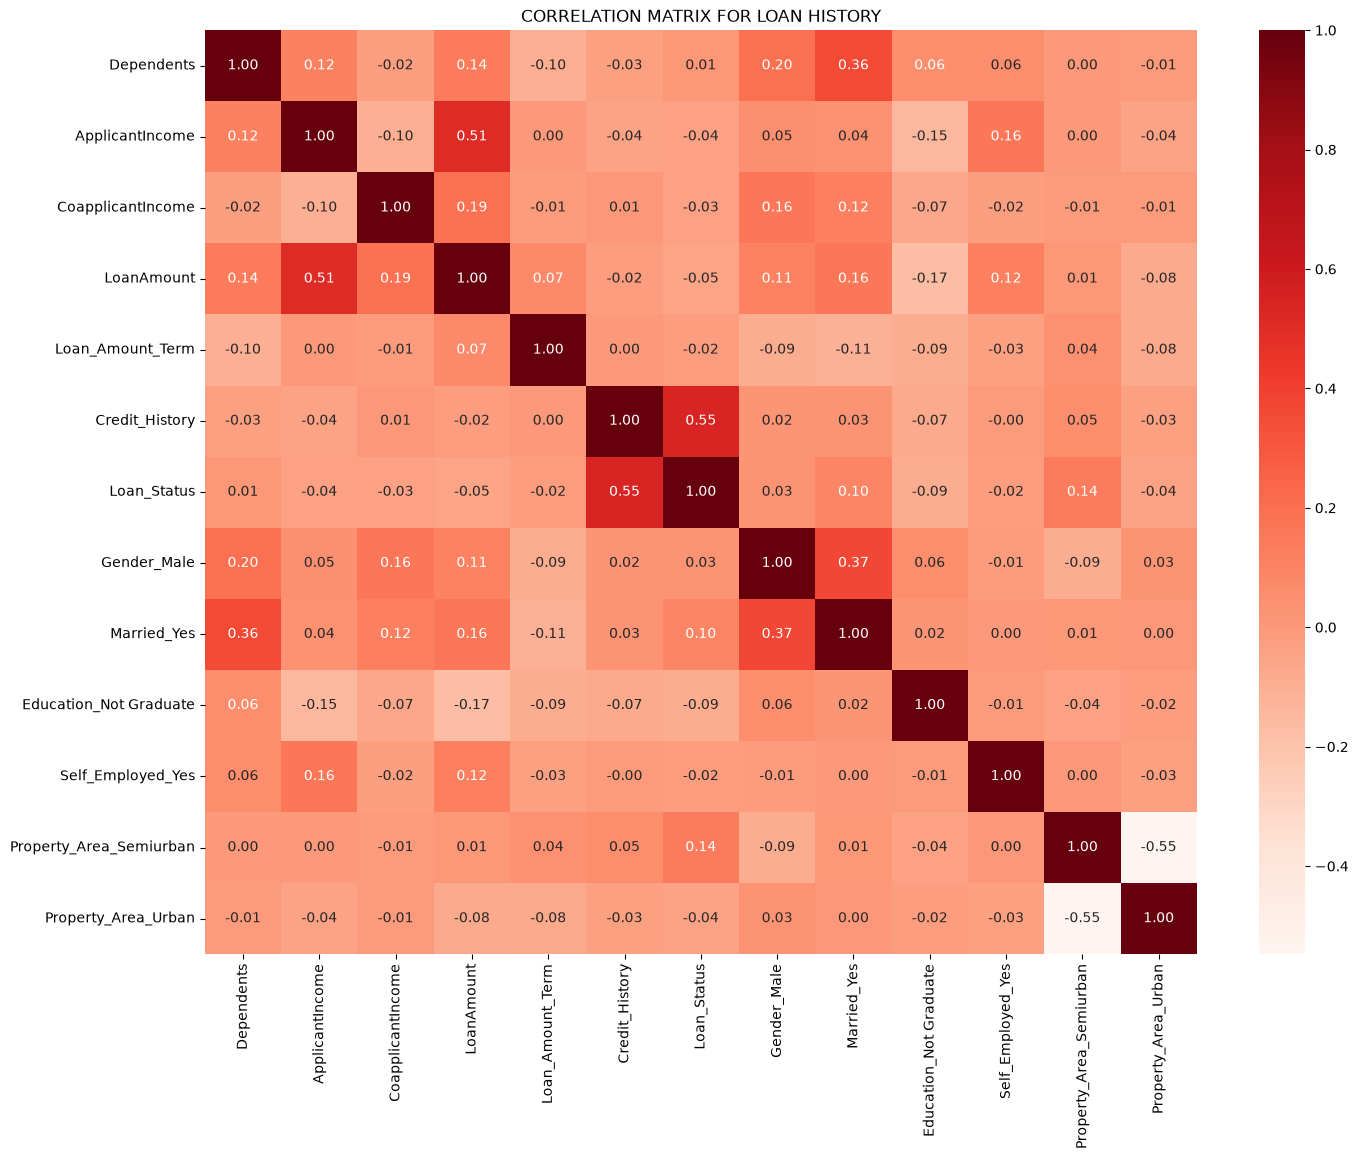

In [18]:
matrix = loan_model_df.drop(columns=['Loan_ID']).corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    matrix,
    cmap='Reds',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 10}
)

plt.title("CORRELATION MATRIX FOR LOAN HISTORY")
plt.show()